## Resource restriction on part of the network
In this notebook, we set up a basic simulation where two vessels move over a 1D network path consisting of three edges. We add a resrouce restriction on the middle edge: only one vessel can use that edge at a time. The second vessel now has to wait until the first vessel has passed the middle edge. 

#### 0. Import libraries

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from pyproj import Geod
from shapely.geometry import Point

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime, time
import simpy
import opentnsim

# package(s) needed for inspecting the output
import pandas as pd
import numpy as np

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.7


#### 1. Define object classes

In [2]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        opentnsim.core.Identifiable, # allows to give the object a name and a random ID,
        opentnsim.core.Movable,      # allows the object to move, with a fixed speed, while logging this activity
    ), 
    {}
)

In [3]:
# make your preferred Node class out of available mix-ins.
Node = type(
    "Node", 
    (
        opentnsim.core.Identifiable, # allows to give the object a name and a random ID, 
        opentnsim.core.Locatable,    # allows the object to have a location
    ),
    {}
)

#### 2. Create graph
Next we create a network (a graph) along which the vessel can move. For this case we create a three edge network: a starting edge of 10 km long, a middle edge of 5 km long and an final edge of 10 km long.

In [4]:
# initialize geodetic calculator with WGS84 ellipsoid
geod = Geod(ellps="WGS84")

In [5]:
# starting point (longitude, latitude)
lon0, lat0 = 0, 0

# compute the other point 100 km East from Point 0
lon1, lat1, _ = geod.fwd(lon0, lat0, 90, 10000) # East from Point 0
lon2, lat2, _ = geod.fwd(lon1, lat1, 90,  5000) # East from Point 1
lon3, lat3, _ = geod.fwd(lon2, lat2, 90, 10000) # East from Point 2

# define nodes with their geographic coordinates
coords = {
    "0": (lon0, lat0),
    "1": (lon1, lat1),
    "2": (lon2, lat2),
    "3": (lon3, lat3),
}

In [6]:
# create list of Node objects
nodes = []
for name, coord in coords.items():
    data_node = {
        "name": name,
        "geometry": Point(coord[0], coord[1])  # Point(longitude, latitude)
    }
    nodes.append(Node(**data_node))

In [7]:
# create list of edges
edges = [
    ("0", "1"), ("1", "0"),
    ("1", "2"), ("2", "1"),
    ("2", "3"), ("3", "2"),
] # bi-directional edge

In [8]:
# create a directed graph
FG = nx.DiGraph()

# add nodes
for node in nodes:
    FG.add_node(node.name, geometry=node.geometry)

# add edges
for edge in edges:
    FG.add_edge(edge[0], edge[1], weight=1)

In [9]:
# extract positions for plotting
positions = {node: (FG.nodes[node]["geometry"].x, FG.nodes[node]["geometry"].y) for node in FG.nodes}

# collect node labels
labels = {node: node for node in FG.nodes}

# compute edge labels as geodesic distances
edge_labels = {}
for u, v in FG.edges():
    lon1, lat1 = positions[u]
    lon2, lat2 = positions[v]
    _, _, dist = geod.inv(lon1, lat1, lon2, lat2)
    edge_labels[(u, v)] = f"{int(dist)} m"

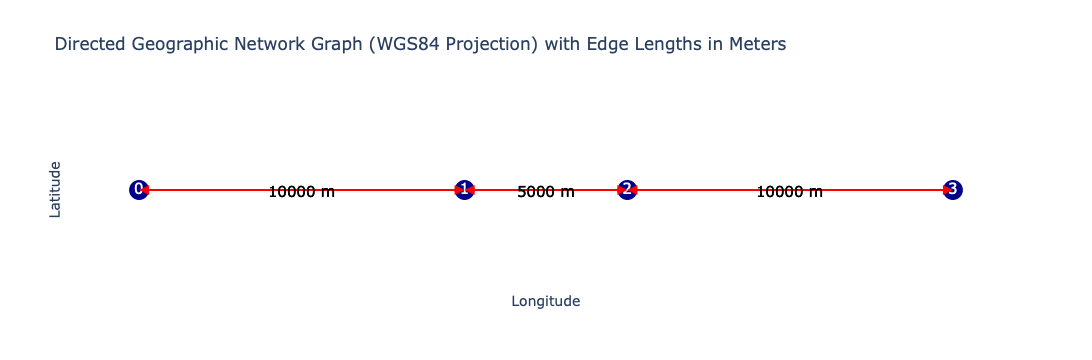

In [10]:
opentnsim.graph.plot_graph(FG)

#### 3. Run simulation

In [11]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [12]:
# start simpy environment
simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start
    
# add sites to graph
FG.edges[('1', '2')]["Resources"] = simpy.Resource(env, 1)

# add graph to environment
env.graph = FG

# create vessel from dict 
data_vessel = {
    "env": env,                                     # needed for simpy simulation, left empty for now
    "name": "Vessel",                               # required by Identifiable
    "geometry": env.graph.nodes['0']['geometry'],   # required by Locatable, left empty for now
    "route": nx.dijkstra_path(env.graph, "0", "3"), # required by Routeable, left empty for now
    "v": 1,                                         # required by Movable, 1 m/s to check if the distance is covered in the expected time
}  
vessel_1 = Vessel(**data_vessel)
vessel_1.name = 'Vessel 1'

vessel_2 = Vessel(**data_vessel)
vessel_2.name = 'Vessel 2'

# start the simulation
env.process(mission(env, vessel_1))
env.process(mission(env, vessel_2))
env.run()

#### 4. Inspect output
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [13]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_1.logbook)

print("'{}' logbook data:".format(vessel_1.name))  
print('')

display(df)

'Vessel 1' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 0 to node 1 start,2024-01-01 00:00:00,0,POINT (0 0)
1,Sailing from node 0 to node 1 stop,2024-01-01 02:46:40,0,POINT (0.0898315284119522 0)
2,Sailing from node 1 to node 2 start,2024-01-01 02:46:40,0,POINT (0.0898315284119522 0)
3,Sailing from node 1 to node 2 stop,2024-01-01 04:10:00,0,POINT (0.1347472926179282 0)
4,Sailing from node 2 to node 3 start,2024-01-01 04:10:00,0,POINT (0.1347472926179282 0)
5,Sailing from node 2 to node 3 stop,2024-01-01 06:56:40,0,POINT (0.2245788210298804 0)


In [14]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_2.logbook)

print("'{}' logbook data:".format(vessel_2.name))  
print('')

display(df)

'Vessel 2' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 0 to node 1 start,2024-01-01 00:00:00,0,POINT (0 0)
1,Sailing from node 0 to node 1 stop,2024-01-01 02:46:40,0,POINT (0.0898315284119522 0)
2,Waiting to pass edge 1 - 2 start,2024-01-01 02:46:40,0,POINT (0.0898315284119522 0)
3,Waiting to pass edge 1 - 2 stop,2024-01-01 04:10:00,0,POINT (0.0898315284119522 0)
4,Sailing from node 1 to node 2 start,2024-01-01 04:10:00,0,POINT (0.0898315284119522 0)
5,Sailing from node 1 to node 2 stop,2024-01-01 05:33:20,0,POINT (0.1347472926179282 0)
6,Sailing from node 2 to node 3 start,2024-01-01 05:33:20,0,POINT (0.1347472926179282 0)
7,Sailing from node 2 to node 3 stop,2024-01-01 08:20:00,0,POINT (0.2245788210298804 0)


The inspection of the logbook data shows that Vessel moved from its origin (*Node 0*) to its destination (*Node 1*). The print statements show that the length of the route from *Node 0* to *Node 1* is exactly 100 km. At a given speed of 1 m/s the trip duration should be exactly 100000 seconds, as is indeed shown to be the case.

In [15]:
# create eventtable from logs
def logbook2eventtable(objs):
    """ objs is a list of objects that has logbook as a property """
    
    events = []
    for obj in objs:
        df = pd.DataFrame.from_dict(obj.logbook)
        for i in range(0, len(df), 2):
            activity = df.iloc[i]['Message'].replace(' start', '')
            
            start_time = df.iloc[i]['Timestamp']
            stop_time = df.iloc[i+1]['Timestamp']
            start_location = df.iloc[i]['Geometry']
            stop_location = df.iloc[i+1]['Geometry']
            
            duration_seconds = (stop_time - start_time).total_seconds()
            distance_meters = opentnsim.graph.calculate_distance(start_location, stop_location)
            
            events.append({
                'object name': obj.name,
                'activity name': activity,
                'start time': start_time,
                'stop time': stop_time,
                'start location': start_location,
                'stop location': stop_location,
                'duration (s)': duration_seconds,
                'distance (m)': distance_meters
            })
        
    # Final DataFrame
    eventtable = pd.DataFrame(events)
    return eventtable


In [16]:
eventtable = logbook2eventtable([vessel_1, vessel_2])
eventtable

,object name,activity name,start time,stop time,start location,stop location,duration (s),distance (m)
0,Vessel 1,Sailing from node 0 to node 1,2024-01-01 00:00:00,2024-01-01 02:46:40,POINT (0 0),POINT (0.0898315284119522 0),10000.0,10000.0
1,Vessel 1,Sailing from node 1 to node 2,2024-01-01 02:46:40,2024-01-01 04:10:00,POINT (0.0898315284119522 0),POINT (0.1347472926179282 0),5000.0,5000.0
2,Vessel 1,Sailing from node 2 to node 3,2024-01-01 04:10:00,2024-01-01 06:56:40,POINT (0.1347472926179282 0),POINT (0.2245788210298804 0),10000.0,10000.0
3,Vessel 2,Sailing from node 0 to node 1,2024-01-01 00:00:00,2024-01-01 02:46:40,POINT (0 0),POINT (0.0898315284119522 0),10000.0,10000.0
4,Vessel 2,Waiting to pass edge 1 - 2,2024-01-01 02:46:40,2024-01-01 04:10:00,POINT (0.0898315284119522 0),POINT (0.0898315284119522 0),5000.0,0.0
5,Vessel 2,Sailing from node 1 to node 2,2024-01-01 04:10:00,2024-01-01 05:33:20,POINT (0.0898315284119522 0),POINT (0.1347472926179282 0),5000.0,5000.0
6,Vessel 2,Sailing from node 2 to node 3,2024-01-01 05:33:20,2024-01-01 08:20:00,POINT (0.1347472926179282 0),POINT (0.2245788210298804 0),10000.0,10000.0


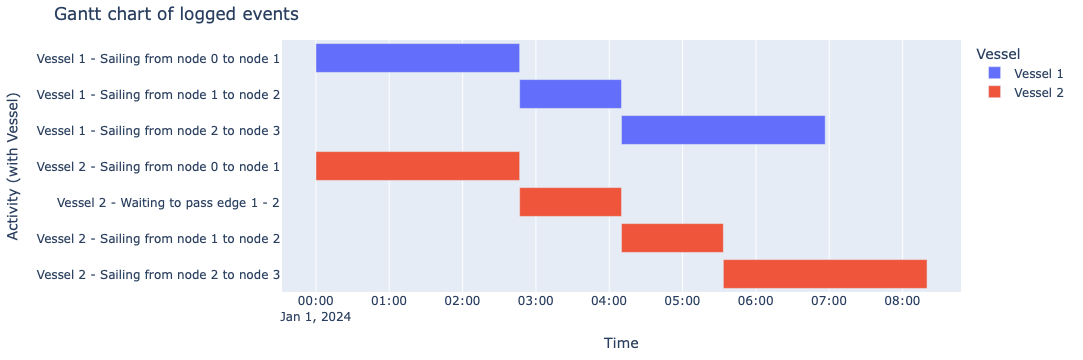

In [17]:
import plotly.express as px

# create a Gantt chart from the eventtable

# add vessel name to activity label
eventtable['activity label'] = eventtable['object name'] + ' - ' + eventtable['activity name']

# create the Gantt chart
fig = px.timeline(
    eventtable,
    x_start="start time",
    x_end="stop time",
    y="activity label",
    color="object name",
    title="Gantt chart of logged events"
)

# reverse the Y-axis to match Gantt chart style
fig.update_yaxes(autorange="reversed")

# customize layout
fig.update_layout(
    xaxis_title="Time",
    yaxis_title="Activity (with Vessel)",
    legend_title="Vessel",
    margin=dict(l=20, r=20, t=40, b=20)
)

# show the chart
fig.show()

The inspection of the logbook data shows that the mission of the Vessel, resulted in four cycles where loading - sailing - unloading - sailing were executed in a sequence. The sites had a capacity of 100, and the Vessel a capacity of 30. It can be seen that the last cycle the loading and unloading take less time because the Vessel sailed only partially filled.